In [1]:
from nns.memorygraphs.memorypool import FoveatedGraphMemory
mem = FoveatedGraphMemory(H=512, W=512)

from nns.cnns.features import RetinaModel, MultiScaleFeatureBank
retina = RetinaModel(edge_apply_gaussian=True, edge_gauss_kernel_size=5, edge_gauss_sigma=1.0)
msbank = MultiScaleFeatureBank(scales=[1.0, 2.0, 4.0], base_sigma=1.0)

In [2]:
from trail.pic_tools import *
from trail.matrix_tools import *
import random
from trail.foveated_visualization1 import visualize_step

In [3]:
image_path = 'picture/OIP-C.jpg' 
tensor, oringinal_image = image_to_tensor(image_path)
B, C, W, H = tensor.shape

retina_out = retina(tensor, center_x = -1, center_y = -1)
cropped = retina_out[5]
msfb_out = msbank(cropped)

In [9]:
x = random.randint(5, H-5)
y = random.randint(5, W-5)
current_fix = (x, y)
mem.set_match_params(min_inliers = 6
                     , edge_preserve_threshold = 0.3
                    #  , inlier_distance_thresh = None
                    #  , score_weights = None
                     )
res = mem.run_one_step(retina_out, msfb_out, current_fix)
print(res['mode'], res['matched'])

strengthen True


(271, 307)


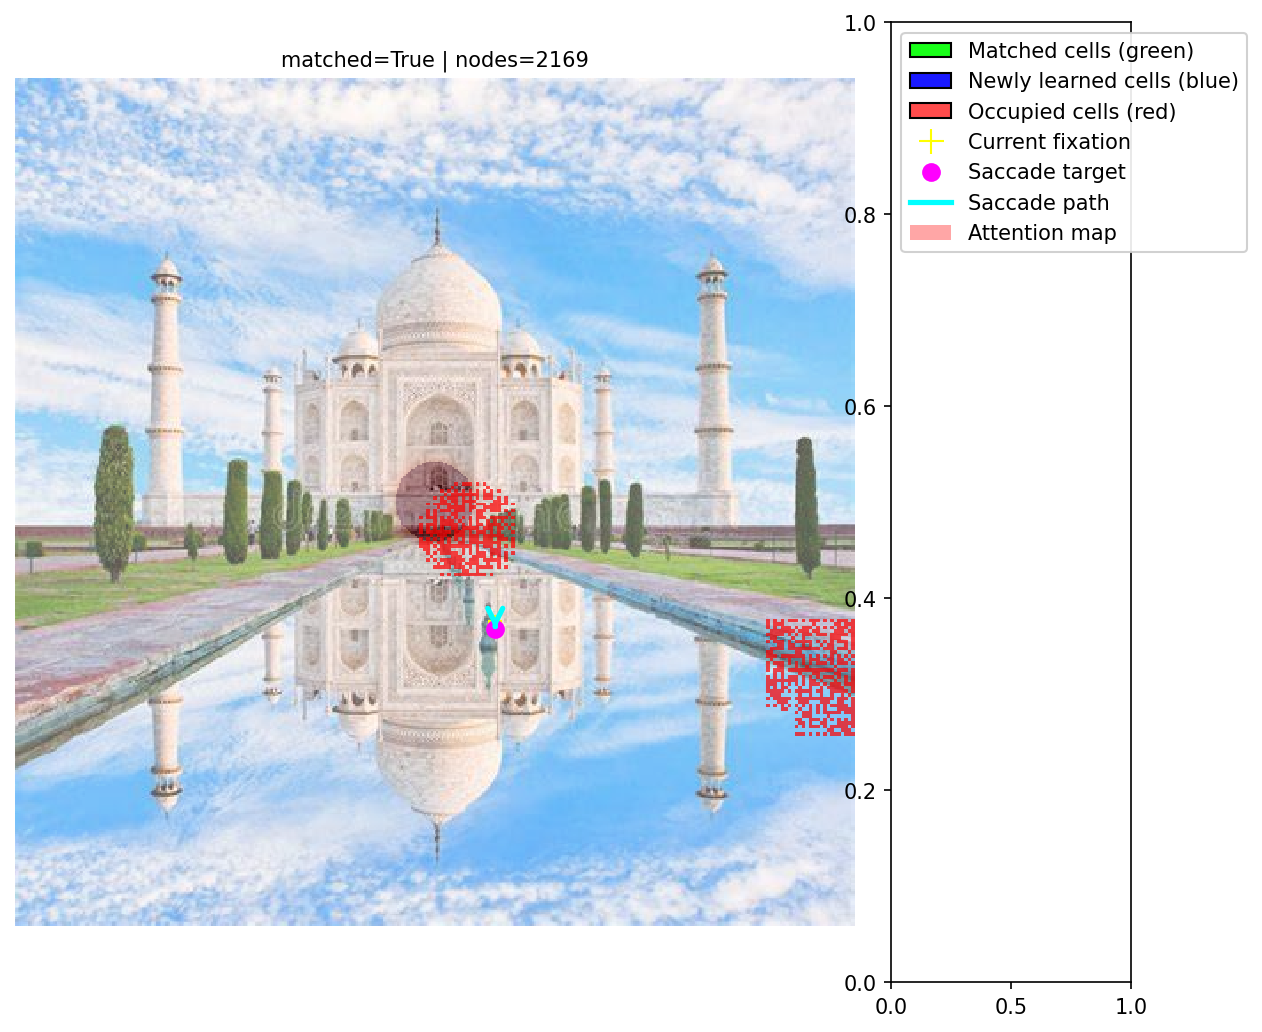

In [10]:
print(current_fix)
visualize_step(oringinal_image, mem, res, current_fix= current_fix)